In [19]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [20]:
# Load the CSV Dataset
df = pd.read_csv("mall_customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


#### Basic EDA (Exploratory Data Analysis)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


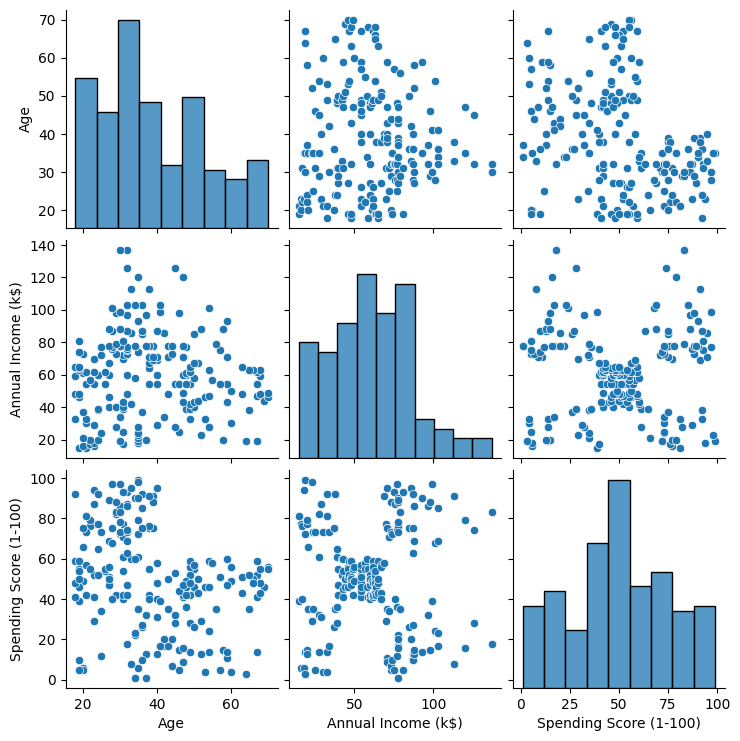

In [21]:
df.info()
df.describe()
df.isnull().sum()
df['Gender'].value_counts()
sns.pairplot(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']])


In [22]:
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})


#### Visualizations

<Axes: xlabel='Age', ylabel='Count'>

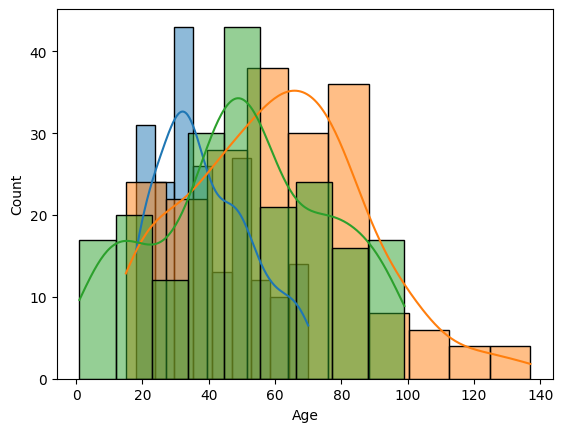

In [23]:
# Distribution plots:
sns.histplot(df['Age'], kde=True)
sns.histplot(df['Annual Income (k$)'], kde=True)
sns.histplot(df['Spending Score (1-100)'], kde=True)


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

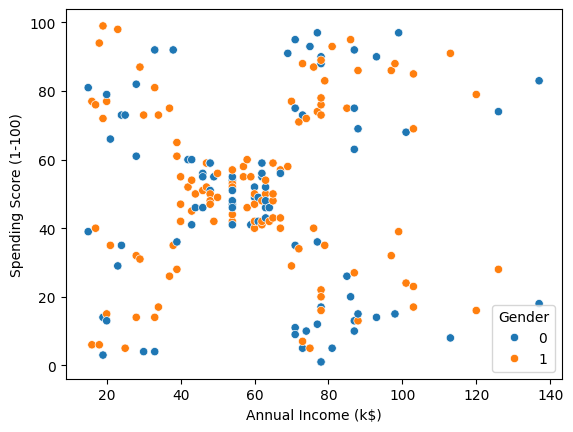

In [24]:
# Relationship plots:
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df, hue='Gender')

#### Clustering using KMeans

In [25]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

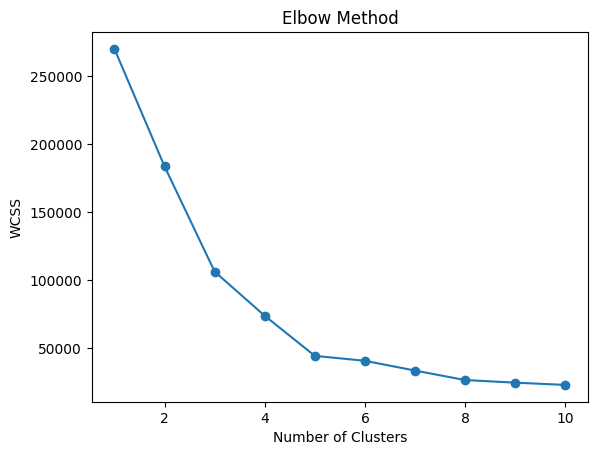

In [26]:
# Elbow Method (to find optimal k)
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

#### Apply KMeans with Optimal Clusters

In [27]:
# Assume k=5 from Elbow Method.
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)


#### Visualize Clusters

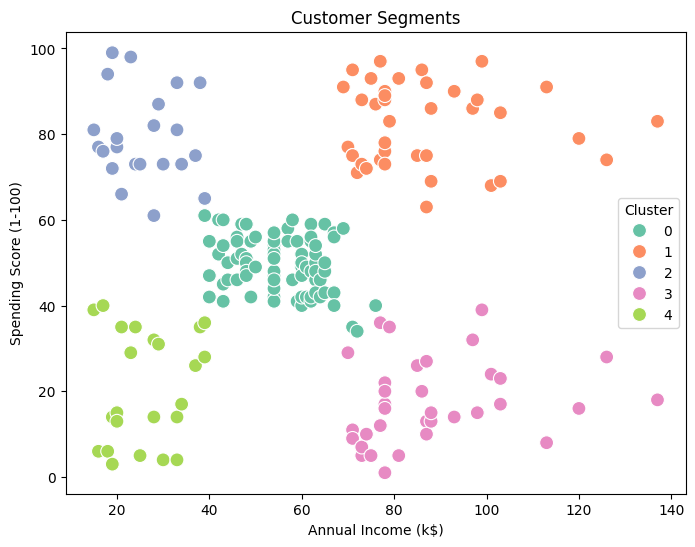

In [28]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', data=df, palette='Set2', s=100)
plt.title("Customer Segments")
plt.show()


#### Cluster Centers

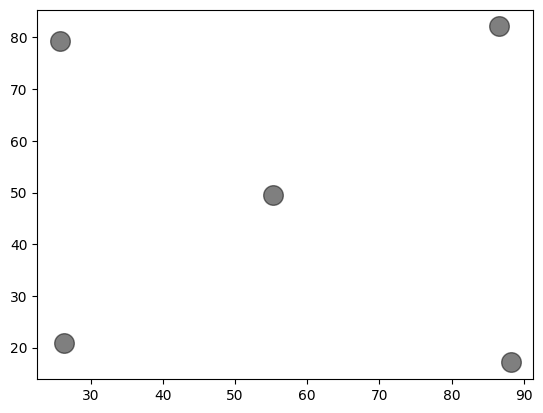

In [29]:
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5, label='Centroids')

#### Save the clustered data

In [30]:
df.to_csv("clustered_customers.csv", index=False)